### Problem Statement:
* Build an image classification model that recognizes hand-drawn/printed English alphabet characters (A–Z) from image input, and integrate it with MediaPipe Hands to recognize alphabets drawn in the air using a webcam in real time.

### Target Classes:
* 26 classes — A to Z (uppercase English alphabets).

### Input Images:
* Images of individual handwritten/printed English alphabet characters

### Importing Required Libraries

In [87]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import joblib


##### Loading Labels

In [ ]:
data_dir = "english_alphabets"

classes = sorted(os.listdir(data_dir))              # Load all class folder names (A–Z) from the dataset directory
print("Classess Found:", classes)
print("Number of Classess:", len(classes))

Classess Found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of Classess: 26


##### Loading the Images

* Loop through each class folder and load every image with its label

In [7]:
images = []
labels = []

for label in classes:

    class_path = os.path.join(data_dir, label)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):

        img_path = os.path.join(class_path, img_file)

        img = cv2.imread(img_path)

        if img is not None:
            images.append(img)
            labels.append(label)

print("Total Number of Images Loaded:", len(images))

Total Number of Images Loaded: 6831


##### Dataset Information

In [ ]:
# Display basic dataset stats (total images, classes, sample shape)
print("Total Number of Images:", len(images))
print("Total Number of Classess:", set(labels))
print("Sample Image Shape:", images[0].shape)

Total Number of Images: 6831
Total Number of Classess: {'W', 'K', 'H', 'C', 'D', 'A', 'V', 'N', 'T', 'F', 'M', 'J', 'X', 'O', 'E', 'Z', 'Q', 'R', 'U', 'G', 'Y', 'B', 'S', 'I', 'L', 'P'}
Sample Image Shape: (34, 34, 3)


##### Sample Images

* Visualize the first 10 loaded images with their labels

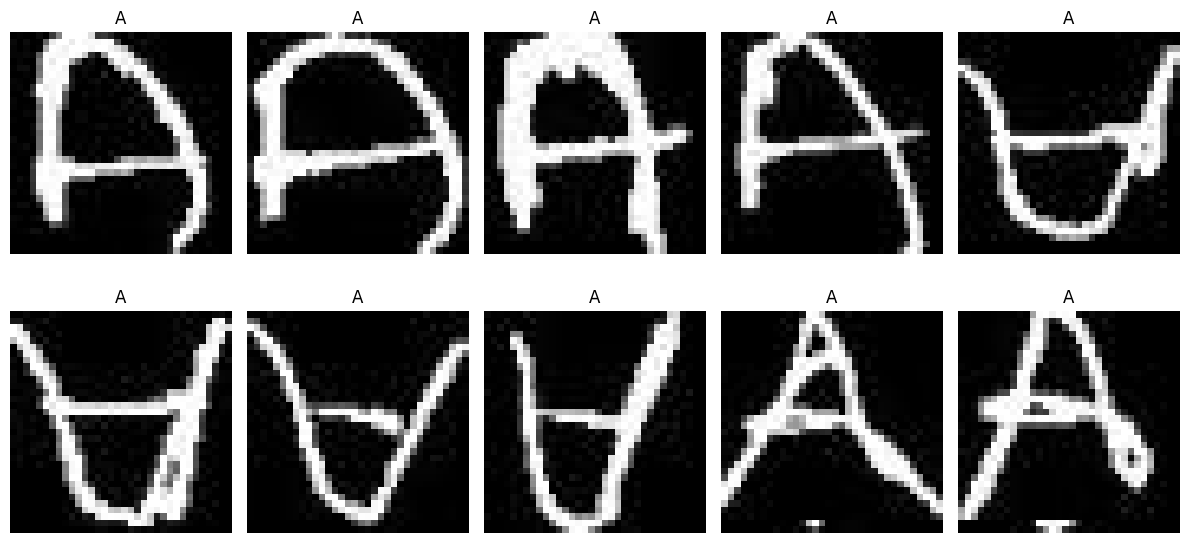

In [9]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(labels[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

##### Image Dimensions

* Check image dimensions for a sample of 200 images

In [10]:
dims = [img.shape for img in images[:200]]
print("Sample dimensions found:", set(dims))

Sample dimensions found: {(34, 34, 3)}


### Dataset Exploration(EDA)

* Create a dataframe of labels for easier exploration/analysis

In [ ]:
df = pd.DataFrame({
    "label": labels
})
print(df.head())
print(df.shape)

  label
0     A
1     A
2     A
3     A
4     A
(6831, 1)


In [ ]:
# Printing quick dataset overview (image count, class count, resolution)
print("Number of Images:", len(images))
print("Number of Classes:", df['label'].nunique())
print("Image Resolution:", images[0].shape)
print("Class Labels:", sorted(df['label'].unique()))

Number of Images: 6831
Number of Classes: 26
Image Resolution: (34, 34, 3)
Class Labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


##### Check file extensions used across the whole dataset

In [ ]:

formats = []

for label in classes:
    folder = os.path.join(data_dir, label)

    for img_file in os.listdir(folder):
        img_path = os.path.join(folder, img_file)
        f = os.path.splitext(img_path)[1]

        formats.append(f)

print("Image Format:", set(formats))

Image Format: {'.jpg'}


* All Images are in .jpg format

##### Class Distribution(counts per class)

* Calculate percentage distribution of images per class

In [29]:
class_counts = df['label'].value_counts().sort_index()
print("\nPercentage Distribution:")
print((class_counts / len(df) * 100).round(2))


Percentage Distribution:
label
A    5.72
B    3.98
C    4.35
D    4.01
E    3.65
F    4.16
G    3.66
H    3.35
I    2.94
J    3.32
K    3.18
L    4.13
M    3.82
N    5.12
O    4.27
P    4.92
Q    3.67
R    3.50
S    3.85
T    3.31
U    3.47
V    3.57
W    3.47
X    3.98
Y    3.07
Z    3.51
Name: count, dtype: float64


Image Analysis  
Analyze  
● Image Height  
● Image Width  
● Color Channels  
● RGB / Grayscale  
● Image Quality  

In [27]:
print("Image Height:", images[0].shape[0])
print("Image Width:", images[0].shape[1])
print("Color Channesl:", images[0].shape[2])
if images[0].shape[2] == 3:
    print("RGB Images")
else:
    print("GrayScale")

print(f"Image Quality: {images[0].shape[0]}x{images[0].shape[0]}")


Image Height: 34
Image Width: 34
Color Channesl: 3
RGB Images
Image Quality: 34x34


##### Count Plot

* Plot number of images per class

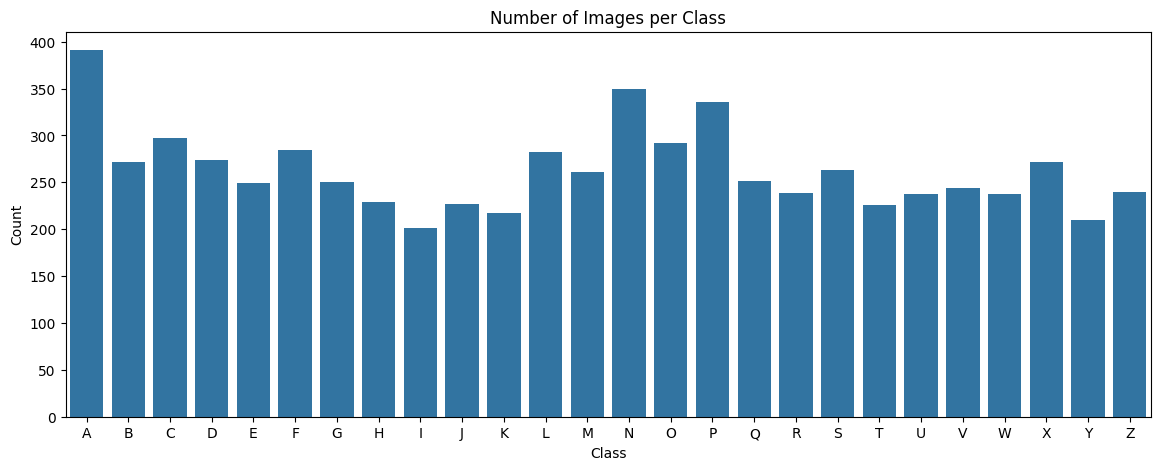

In [14]:
plt.figure(figsize=(14, 5))
sns.countplot(x='label', data=df, order=sorted(df['label'].unique()))
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

##### Sample Images from each class

* Displaying one sample image from each class in a grid

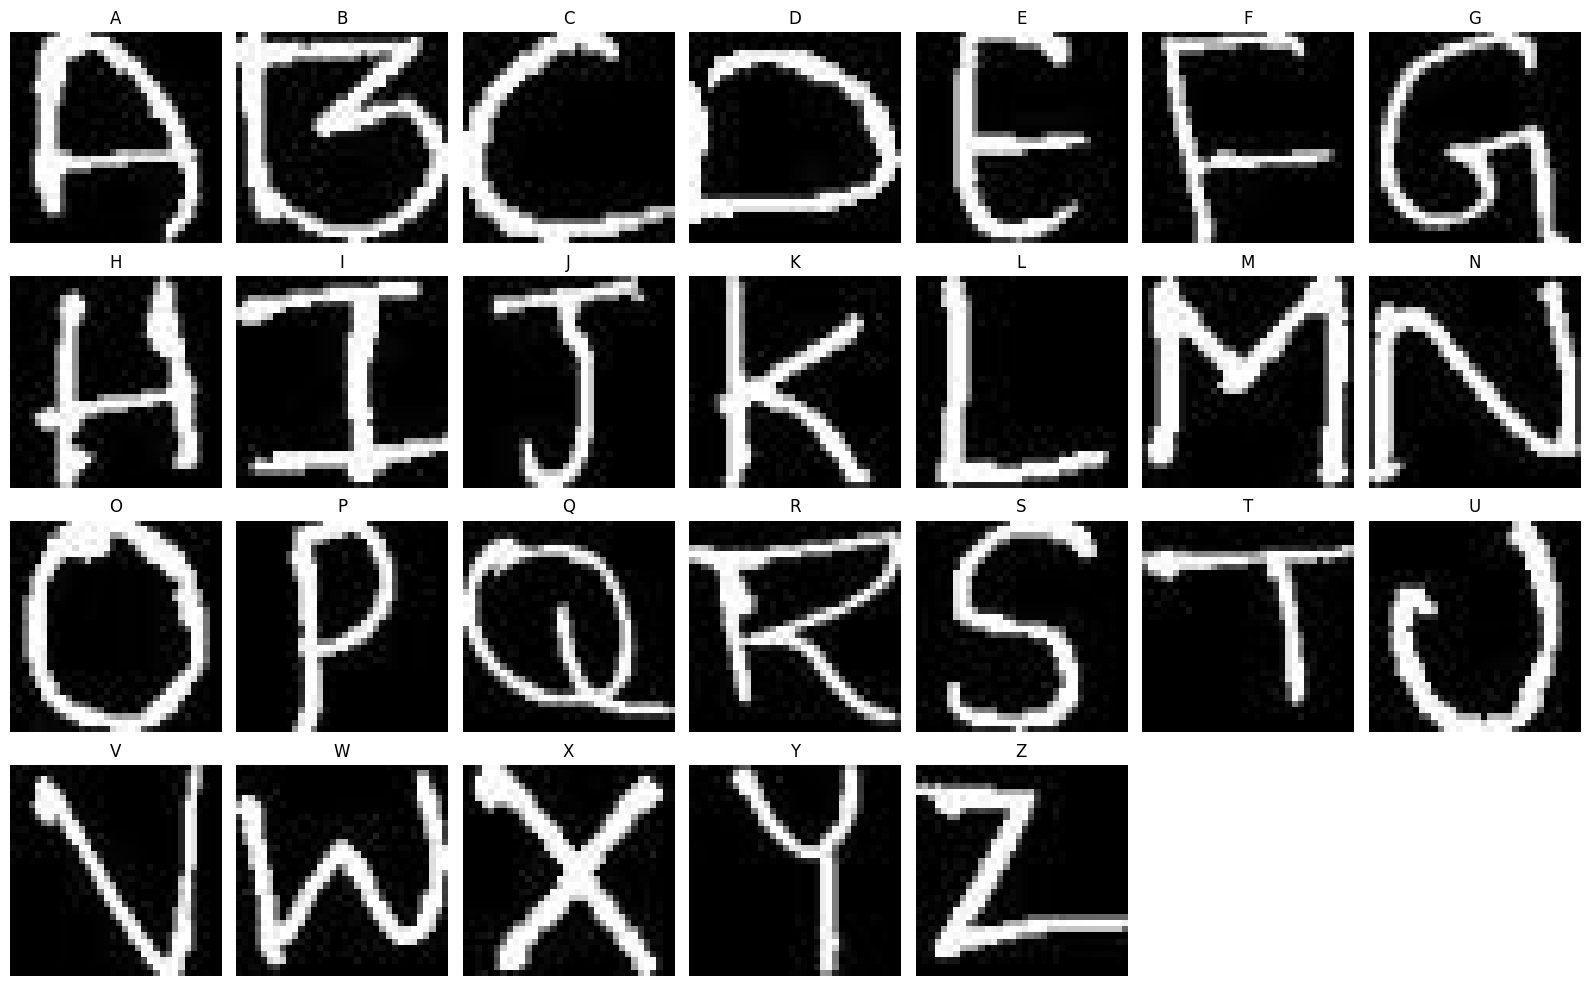

In [15]:
fig, axes = plt.subplots(4, 7, figsize=(16, 10))
axes = axes.flatten()

classes_sorted = sorted(set(labels))
for i, label in enumerate(classes_sorted):
    idx = labels.index(label)  # first image found for that class
    axes[i].imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
    axes[i].set_title(label)
    axes[i].axis('off')

# hide unused subplots (26 classes in a 4x7=28 grid, 2 empty)
for j in range(len(classes_sorted), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

##### Dimensions of all Images

* Checking image dimensions across the FULL dataset.

In [16]:
all_dims = [img.shape for img in images]
print("Unique dimensions across FULL dataset:", set(all_dims))

Unique dimensions across FULL dataset: {(34, 34, 3)}


* Building a table showing image count per class

In [28]:
class_count_df = df['label'].value_counts().sort_index().reset_index()
class_count_df.columns = ['Class', 'Image_Count']
print(class_count_df)

   Class  Image_Count
0      A          391
1      B          272
2      C          297
3      D          274
4      E          249
5      F          284
6      G          250
7      H          229
8      I          201
9      J          227
10     K          217
11     L          282
12     M          261
13     N          350
14     O          292
15     P          336
16     Q          251
17     R          239
18     S          263
19     T          226
20     U          237
21     V          244
22     W          237
23     X          272
24     Y          210
25     Z          240


### Image Preprocessing

##### Resizing the Images 
**Note:** Since the images are already in 34x34 in size i choose not to resize them further

##### RGB ----> Grayscale
* Convert all images from BGR to grayscale

In [30]:
grays = []

for img in images:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    grays.append(img)    

* Converted the images to Gray Scale

##### Normalizing Pixel values

* Normalize pixel values from 0–255 to 0–1 range

In [37]:
normalized = []

for img in grays:
    img = img.astype('float32') / 255.0

    normalized.append(img)

normalized = np.array(normalized)

print("Minimum Pixel Value:",normalized.min())
print("Maximum Pixel Value:",normalized.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


##### Checking Corrupted Files

* Scanning dataset for corrupted/unreadable image files

In [40]:
corrupted = []

for label in classes:
    folder = os.path.join(data_dir, label)

    for img_file in os.listdir(folder):
        img_path = os.path.join(folder, img_file)
        ext = os.path.splitext(img_path)[1].lower()

        if ext == '.jpg':
            img = cv2.imread(img_path)

            if img is None:
                corrupted.append(img_path)

print("Number of Corrupted Images:", len(corrupted))

Number of Corrupted Images: 0


###  Feature Extraction

* Extract HOG (Histogram of Oriented Gradients) features from all images

In [42]:
X_hog = np.array([hog(img, pixels_per_cell=(8,8), cells_per_block=(2,2)) 
                   for img in normalized])
print("HOG feature shape:", X_hog.shape)

HOG feature shape: (6831, 324)


### Input-Output Separation

In [43]:
# Input (X) - HOG features
X = X_hog

# Output (y) - Class Labels
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6831, 324)
y shape: (6831,)


### Train-Test Split

* Split data into training and test sets (80/20, stratified by class)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5464, 324)
X_test shape: (1367, 324)
y_train shape: (5464,)
y_test shape: (1367,)


### Encoding the Labels

* Convert string class labels (A–Z) into numeric form

In [49]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Classes:", le.classes_)

Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


### Model Building

* Training and evaluating 5 baseline models to compare initial accuracy

In [51]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.9276
Decision Tree Accuracy: 0.7059
Random Forest Accuracy: 0.9247
KNN Accuracy: 0.9327
Naive Bayes Accuracy: 0.8420


##### Comparing all Baseline Models Accuracy

* Comparing baseline model accuracies in a sorted table

In [52]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print(results_df)

                 Model  Accuracy
3                  KNN  0.932699
0  Logistic Regression  0.927579
2        Random Forest  0.924653
4          Naive Bayes  0.841990
1        Decision Tree  0.705925


* Visualize baseline model comparison as a bar chart

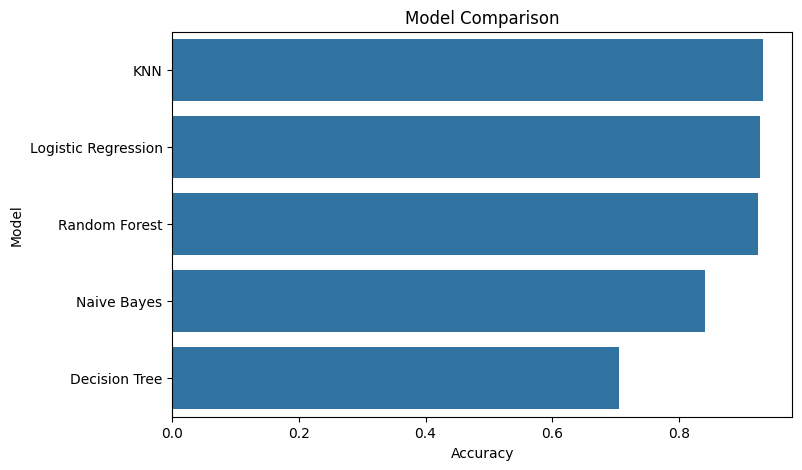

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=results_df)
plt.title("Model Comparison")
plt.xlabel("Accuracy")
plt.show()

### Hyperparameter Tuning

* Hyperparameter tuning for KNN using GridSearchCV

In [61]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train_encoded)

print("Best KNN Params (GridSearch):", knn_grid.best_params_)
print("Best KNN CV Accuracy (GridSearch):", knn_grid.best_score_)

Best KNN Params (GridSearch): {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV Accuracy (GridSearch): 0.9313682810023158


* Hyperparameter tuning for Logistic Regression

In [62]:
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga']  
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train_encoded)

print("Best LR Params:", lr_grid.best_params_)
print("Best LR CV Accuracy:", lr_grid.best_score_)

Best LR Params: {'C': 1, 'solver': 'saga'}
Best LR CV Accuracy: 0.9141638934411122


* Hyperparameter tuning for Random Forest

In [63]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train_encoded)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV Accuracy:", rf_grid.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best RF CV Accuracy: 0.9209344178237135


##### Comparing a Three Tuned Models

* Comparing cross-validation accuracy of all three tuned models

In [66]:
tuned_results = {
    "KNN (Tuned)": knn_grid.best_score_,
    "Logistic Regression (Tuned)": lr_grid.best_score_,
    "Random Forest (Tuned)": rf_grid.best_score_
}

tuned_df = pd.DataFrame(list(tuned_results.items()), columns=['Model', 'CV Accuracy'])
tuned_df = tuned_df.sort_values(by='CV Accuracy', ascending=False)
print(tuned_df)

                         Model  CV Accuracy
0                  KNN (Tuned)     0.931368
2        Random Forest (Tuned)     0.920934
1  Logistic Regression (Tuned)     0.914164


### Model Evaluation

##### Evaluating all three tuned Models

In [73]:


models = {
    "KNN": knn_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='weighted')
    recall = recall_score(y_test_encoded, y_pred, average='weighted')
    f1 = f1_score(y_test_encoded, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

tuned_results = pd.DataFrame(results)
tuned_results = tuned_results.sort_values(by='Accuracy', ascending = False)
tuned_results

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.934894,0.935175,0.934894,0.934249
2,Logistic Regression,0.929042,0.929869,0.929042,0.928834
1,Random Forest,0.925384,0.926744,0.925384,0.925031


* KNN has the best results in Accuracy, Precision, Recall, F1-Score, It is choosen as final model

##### Classification Report

* Plot confusion matrix heatmap for the final KNN model

In [77]:
y_pred = knn_grid.best_estimator_.predict(X_test)

# Classification report
print("Classification Report:")
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=le.classes_
))

Classification Report:
              precision    recall  f1-score   support

           A       0.99      1.00      0.99        78
           B       0.96      0.98      0.97        54
           C       0.92      1.00      0.96        60
           D       0.93      0.91      0.92        55
           E       0.86      0.86      0.86        50
           F       0.89      0.89      0.89        57
           G       0.96      0.90      0.93        50
           H       0.93      0.93      0.93        46
           I       0.84      0.90      0.87        40
           J       0.89      0.73      0.80        45
           K       0.90      0.86      0.88        43
           L       0.96      0.89      0.93        57
           M       0.98      0.98      0.98        52
           N       0.93      1.00      0.97        70
           O       0.90      0.93      0.92        59
           P       0.97      0.99      0.98        67
           Q       0.91      1.00      0.95        50
    

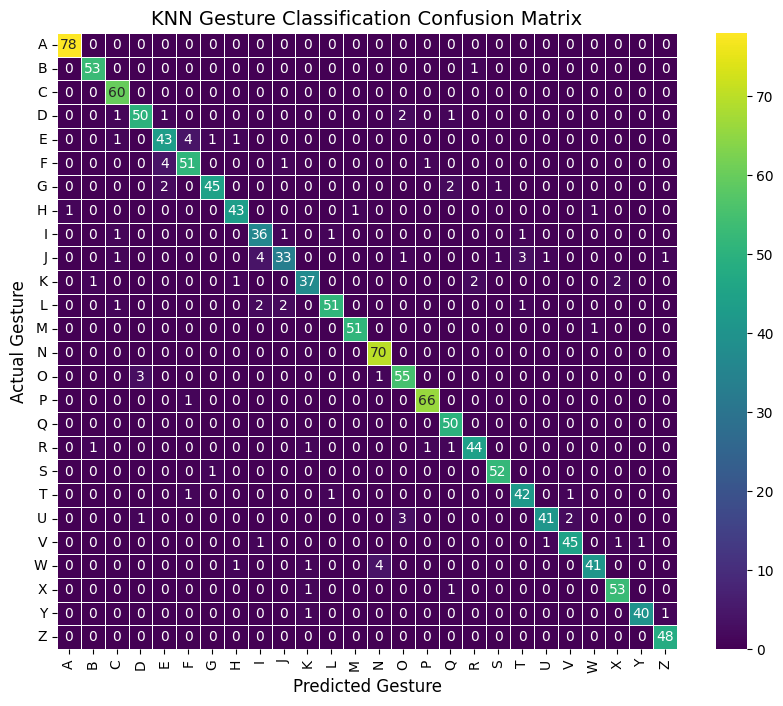

In [86]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    linewidths=0.5,
    linecolor='white',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Gesture", fontsize=12)
plt.ylabel("Actual Gesture", fontsize=12)
plt.title("KNN Gesture Classification Confusion Matrix", fontsize=14)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

### Saving the Model

In [88]:
joblib.dump(knn_grid.best_estimator_, "knn_gesture_model.pkl")

print("KNN model saved successfully!")

KNN model saved successfully!


### Saving the Encoder

In [90]:
joblib.dump(le, "label_encoder.pkl")

print("Label encoder saved successfully!")

Label encoder saved successfully!


### Saving HOG Parameters

In [91]:
hog_params = {
    "pixels_per_cell": (8,8),
    "cells_per_block": (2,2)
}

joblib.dump(
    hog_params,
    "hog_params.pkl"
)

print("HOG parameters saved!")

HOG parameters saved!
